# Stability vs. Flexibility Segregation — a step-through tutorial

This notebook decomposes `stability_flexibility_segregation.py` into runnable
pieces so you can **see what each function does to the data**, with a plot at
every step. The production code lives in
`src/analysis/stats/stability_flexibility_segregation.py`; here we pull it
apart and rebuild it cell by cell.

## The scientific question

In the Global/Local task, **stability** is indexed by the *congruency* effect
(and its list-wide proportion modulation, LWPC) and **flexibility** by the
*switch* effect (LWPS). We want to know, at the level of single iEEG
electrodes:

> Do **distinct subpopulations** uniquely support stability vs. flexibility
> (*segregation*), or does a **shared, domain-general core** carry both
> (*overlap*)?

We answer this with the **joint distribution** of two per-electrode
sensitivities:

- `x` = stability sensitivity (incongruent − congruent high-gamma)
- `y` = flexibility sensitivity (switch − repeat high-gamma)

and ask whether `x` and `y` are **correlated across electrodes**:

| Result | Interpretation |
|---|---|
| corr ≤ 0 / odds-ratio < 1 | **segregated** — an electrode good at one tends *not* to be good at the other |
| corr > 0 / odds-ratio > 1 | **shared core** — the same electrodes do both |

## The trap: shared noise fakes a positive correlation

Two nuisances inflate `corr(x, y)` even when the truth is zero:

1. **Shared trial noise** — if `x` and `y` are estimated from the *same trials*,
   each trial's noise leaks into both estimates, correlating them spuriously.
   → **Fix:** estimate `x` and `y` on **disjoint trial halves**.
2. **Shared gain / SNR** — a high-SNR electrode shows a bigger effect for
   *everything*, so `|x|` and `|y|` co-inflate.
   → **Fix:** **residualize** `x` and `y` on overall responsiveness.

Subject nesting is handled by **within-subject centering + within-subject
permutation** (continuous test) and **CMH stratification** (categorical test).

We'll build up to two complementary tests:
- **(B) Continuous** — subject-clustered partial correlation of `x` vs `y`.
- **(C) Categorical** — subject-stratified Cochran–Mantel–Haenszel 2×2 conjunction.

Run the cells top to bottom. By default the notebook uses **synthetic**
data with known ground truth so it executes anywhere; flip `DATA_SOURCE`
in §1 to run every step on **your real iEEG data** instead.

## 0 · Setup

We import the plotting stack and add the repo root to `sys.path` so we can
`import` the production functions (we reuse the *real* helpers throughout, then
inline their internals where it's instructive).

In [1]:
%matplotlib inline
import sys, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Locate the repo root (this notebook lives in src/analysis/stats/).
CWD = os.getcwd()
repo_root = CWD
for _ in range(6):
    if os.path.exists(os.path.join(repo_root, "setup.py")):
        break
    repo_root = os.path.dirname(repo_root)
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)
print("repo root:", repo_root)

# The production module we are dissecting.
from src.analysis.stats import stability_flexibility_segregation as sfs

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True,
                     "grid.alpha": 0.25, "axes.spines.top": False,
                     "axes.spines.right": False, "font.size": 10})
STAB, FLEX = "#2c7fb8", "#d95f0e"   # blue = stability, orange = flexibility
print("loaded", sfs.__name__)

repo root: /hpc/group/coganlab/jz421/GlobalLocal
loaded src.analysis.stats.stability_flexibility_segregation


## 1 · Load your data — real or synthetic

The input `df` is **long format**: one row per (electrode, trial) with columns
`subject, electrode, hg, congruency ∈ {c,i}, switchType ∈ {s,r}`.

Set **`DATA_SOURCE`** below:

- **`"synthetic"`** (default) — generate data where we *control the truth*, to
  validate the pipeline. Each electrode has latent sensitivities `(bx, by)` drawn
  from a bivariate normal with correlation **`RHO_TRUE`** (0 = segregated, >0 =
  shared core), a random **`gain`** (SNR) that multiplies *both* effects (the
  confound residualization must remove), and single-trial
  HG = `gain·(bx·[congruent=i] + by·[switch=s]) + gain·noise`.
- **`"real"`** — your iEEG data, provided one of two ways:
  - **option A** — point `LONG_DF_CSV` at a pre-assembled long table. The
    production pipeline (`dcc_scripts/stats/…_dcc.py`) writes exactly this file
    as `long_df.csv`, so you can iterate here without reloading epochs.
  - **option B** — set `SUBJECTS` + `EPOCHS_ROOT_FILE` and the notebook
    assembles `df` from epoched data using the **same** helpers
    (`load_HG_ev1_rescaled_per_subject` + `assemble_long_df`) the cluster job
    uses, so notebook and pipeline build `df` identically.

Everything downstream is source-agnostic — the same diagnostic cells run either
way.

In [ ]:
# =============================================================================
# CHOOSE YOUR DATA SOURCE
# =============================================================================
DATA_SOURCE = "synthetic"       # <-- set to "real" to run on your iEEG data

# --- synthetic knobs (ignored when DATA_SOURCE == "real") --------------------
RHO_TRUE = 0.40      # ground-truth corr between bx and by (0.0 = segregated null)
GAIN_SD  = 0.5       # spread of per-electrode SNR (the gain confound)

# --- REAL, option A: a pre-assembled long-format CSV -------------------------
# The production pipeline writes this as `long_df.csv`. Point LONG_DF_CSV at it
# to iterate here without reloading epochs. Columns:
#   subject, electrode, hg, congruency, switchType
LONG_DF_CSV = None              # e.g. r"/path/to/results/<tag>/long_df.csv"

# --- REAL, option B: assemble from epoched data (needs Box/CoganLab access) --
# Reuses the SAME helpers as the cluster job, so df is built identically.
SUBJECTS         = ["D0057", "D0059", "D0063"]   # <-- your subject list
EPOCHS_ROOT_FILE = None         # e.g. "Stimulus_1sec_preStimulusBase..." (required for option B)
TASK             = "GlobalLocal"
WINDOW_TMIN, WINDOW_TMAX = 0.0, 0.5   # analysis window (s); HG is window-averaged
ACC_TRIALS_ONLY  = True
LAB_ROOT         = None         # None -> auto-resolved

# --- responsiveness (gain control) used in §5. On real data, PREFER passing
#     your baseline-vs-signal time_perm_cluster stat as {electrode: value}. ---
RESPONSIVENESS = None           # None -> mean|HG| proxy


def make_synthetic(rho_true=RHO_TRUE, n_subj=10, seed=0, gain_sd=GAIN_SD):
    rng = np.random.default_rng(seed)
    cov = np.array([[0.4**2, rho_true*0.4*0.4], [rho_true*0.4*0.4, 0.4**2]])
    rows, truth = [], []
    for s in range(n_subj):
        n_tr = int(rng.integers(280, 420))
        cong = rng.choice(["c", "i"], n_tr)
        sw   = rng.choice(["s", "r"], n_tr)
        for e in range(int(rng.integers(15, 26))):
            gain = rng.lognormal(0, gain_sd)                 # per-electrode SNR
            bx, by = rng.multivariate_normal([0, 0], cov)    # true sensitivities
            hg = (gain * (bx * (cong == "i") + by * (sw == "s"))
                  + rng.normal(0, 1, n_tr) * gain)
            eid = f"{s}_{e}"
            rows.append(pd.DataFrame(dict(subject=s, electrode=eid, hg=hg,
                                          congruency=cong, switchType=sw)))
            truth.append(dict(electrode=eid, subject=s, bx=bx, by=by, gain=gain))
    return pd.concat(rows, ignore_index=True), pd.DataFrame(truth)


def load_real_df():
    """Build the long-format df from real data: CSV if given, else epochs."""
    if LONG_DF_CSV:
        d = pd.read_csv(LONG_DF_CSV)
        need = {"subject", "electrode", "hg", "congruency", "switchType"}
        missing = need - set(d.columns)
        if missing:
            raise ValueError(f"{LONG_DF_CSV} is missing columns: {missing}")
        return d.dropna(subset=["hg"]).reset_index(drop=True)
    # option B: assemble from epochs using the production helpers
    if not EPOCHS_ROOT_FILE:
        raise ValueError("For DATA_SOURCE='real', set LONG_DF_CSV (option A) "
                         "or SUBJECTS + EPOCHS_ROOT_FILE (option B).")
    from src.analysis.utils.general_utils import load_HG_ev1_rescaled_per_subject
    from dcc_scripts.stats.stability_flexibility_segregation_dcc import (
        assemble_long_df, resolve_lab_root)
    subjects_epochs = load_HG_ev1_rescaled_per_subject(
        subjects=SUBJECTS, epochs_root_file=EPOCHS_ROOT_FILE, task=TASK,
        LAB_root=resolve_lab_root(LAB_ROOT), acc_trials_only=ACC_TRIALS_ONLY)
    return assemble_long_df(subjects_epochs, WINDOW_TMIN, WINDOW_TMAX)


if DATA_SOURCE == "real":
    df = load_real_df()
    truth = None                         # no ground truth for real data
    TRUTH_LABEL = ""
else:
    df, truth = make_synthetic()
    TRUTH_LABEL = f"  (truth RHO={RHO_TRUE})"

print(f"DATA_SOURCE = {DATA_SOURCE}")
print("rows:", len(df), "| subjects:", df.subject.nunique(),
      "| electrodes:", df.electrode.nunique())
df.head()

### Look at the data before touching it

Trial counts and electrode counts are deliberately **unequal** across subjects
(as in real iEEG), and per-electrode HG scale varies with `gain`. Always eyeball
this structure — it's what motivates the subject-aware, gain-corrected design.

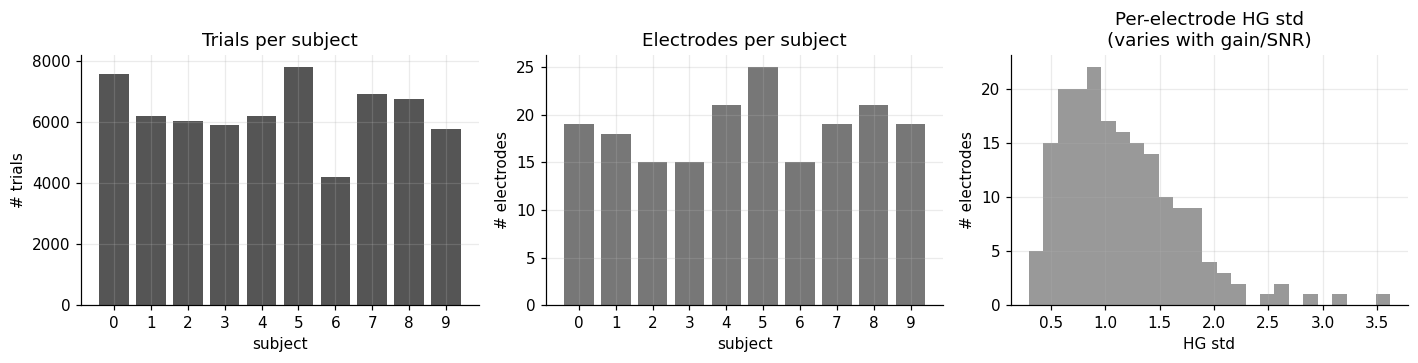

In [6]:
fig, ax = plt.subplots(1, 3, figsize=(13, 3.4))

tr = df.groupby("subject").size()
ax[0].bar(tr.index.astype(str), tr.values, color="#555")
ax[0].set(title="Trials per subject", xlabel="subject", ylabel="# trials")

ne = df.groupby("subject")["electrode"].nunique()
ax[1].bar(ne.index.astype(str), ne.values, color="#777")
ax[1].set(title="Electrodes per subject", xlabel="subject", ylabel="# electrodes")

# per-electrode mean |HG| spread (reflects the gain confound)
gvar = df.groupby("electrode")["hg"].std()
ax[2].hist(gvar.values, bins=25, color="#999")
ax[2].set(title="Per-electrode HG std\n(varies with gain/SNR)", xlabel="HG std",
          ylabel="# electrodes")
plt.tight_layout(); plt.show()

## 2 · `_cohens_d` — the atom of every sensitivity

Every effect in this analysis is a **standardized mean difference** (Cohen's
*d*) between two trial groups:

$$d = \frac{\bar a - \bar b}{s_\text{pooled}}, \qquad
s_\text{pooled}=\sqrt{\tfrac{(n_a-1)\,\mathrm{Var}(a)+(n_b-1)\,\mathrm{Var}(b)}{n_a+n_b-2}}$$

Standardizing (rather than using the raw mean difference) is what starts to put
electrodes of different gain on a comparable footing. It returns `NaN` when a
group has < 2 trials so downstream `np.nanmean` can ignore it.

Let's compute the **stability** contrast `d(i − c)` for one electrode and *see*
the two distributions it compares.

electrode 0_0:  d(incongruent - congruent) = +0.055


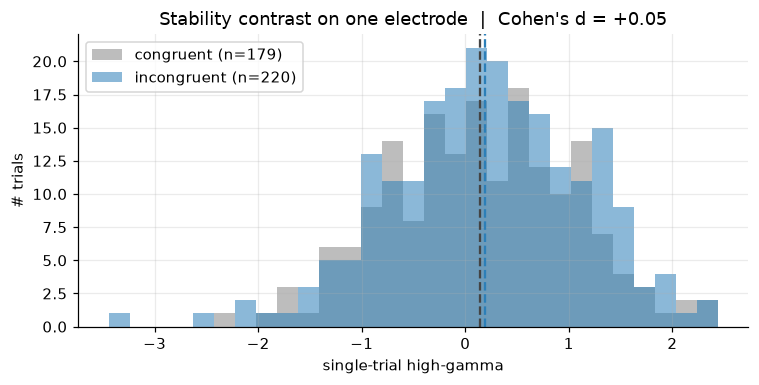

In [4]:
elec0 = df.electrode.iloc[0]
sub0 = df[df.electrode == elec0]
hg_i = sub0.loc[sub0.congruency == "i", "hg"]
hg_c = sub0.loc[sub0.congruency == "c", "hg"]

d_stab = sfs._cohens_d(hg_i, hg_c)     # exactly what the pipeline calls
print(f"electrode {elec0}:  d(incongruent - congruent) = {d_stab:+.3f}")

fig, ax = plt.subplots(figsize=(7, 3.6))
bins = np.linspace(min(sub0.hg), max(sub0.hg), 30)
ax.hist(hg_c, bins=bins, alpha=.55, color="#888", label=f"congruent (n={len(hg_c)})")
ax.hist(hg_i, bins=bins, alpha=.55, color=STAB, label=f"incongruent (n={len(hg_i)})")
ax.axvline(hg_c.mean(), color="#444", ls="--"); ax.axvline(hg_i.mean(), color=STAB, ls="--")
ax.set(title=f"Stability contrast on one electrode  |  Cohen's d = {d_stab:+.2f}",
       xlabel="single-trial high-gamma", ylabel="# trials")
ax.legend(); plt.tight_layout(); plt.show()

## 3 · `_stratified_half_split` — disjoint, balanced trial halves

The central trick for killing **shared trial noise** is to estimate `x` and `y`
from *different trials*. But a naive random split could hand one half more
incongruent-switch trials than the other, confounding the contrasts. So the
split is **stratified**: within each `congruency × switchType` cell, trials are
shuffled and cut in half. Each half then has a balanced mix, and the two halves
are **disjoint**.

half sizes: 198 201 | overlap: 0


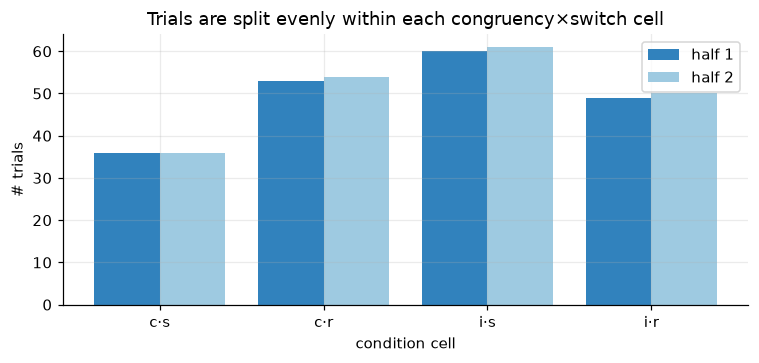

In [5]:
rng = np.random.default_rng(0)
sub0r = sub0.reset_index(drop=True)
h1, h2 = sfs._stratified_half_split(sub0r, rng)

print("half sizes:", len(h1), len(h2), "| overlap:", len(set(h1) & set(h2)))

def cell_counts(idx):
    g = sub0r.loc[idx].groupby(["congruency", "switchType"]).size()
    return [g.get((c, s), 0) for c in "ci" for s in "sr"]
labels = ["c·s", "c·r", "i·s", "i·r"]
c1, c2 = cell_counts(h1), cell_counts(h2)

fig, ax = plt.subplots(figsize=(7, 3.4))
xpos = np.arange(4)
ax.bar(xpos - .2, c1, .4, label="half 1", color="#3182bd")
ax.bar(xpos + .2, c2, .4, label="half 2", color="#9ecae1")
ax.set_xticks(xpos); ax.set_xticklabels(labels)
ax.set(title="Trials are split evenly within each congruency×switch cell",
       xlabel="condition cell", ylabel="# trials"); ax.legend()
plt.tight_layout(); plt.show()

## 4 · `compute_sensitivities` — and *why disjoint halves matter*

For each electrode, over `n_splits` random disjoint splits:
- estimate `x` (congruency *d*) on one half,
- estimate `y` (switch *d*) on the **other** half,
- (halves are swapped 50/50 so both are used symmetrically),
- average `x` and `y` over all splits.

Because `x` and `y` never share a trial within a split, their **sampling noise
is independent** — so noise cannot manufacture a correlation.

### Demonstration: naive (same-trials) estimation inflates corr(x, y)

Below we generate a dataset with **`RHO_TRUE = 0`** (truly segregated) and
compare two estimators of per-electrode `(x, y)`:
- **naive** — both contrasts on *all* trials (shared noise), and
- **disjoint** — the pipeline's split estimator.

Watch the naive scatter show a spurious positive tilt that the disjoint
estimator removes. *(This demonstration always uses synthetic `rho=0` data
— it illustrates a property of the estimator, independent of your
`DATA_SOURCE` choice above.)*

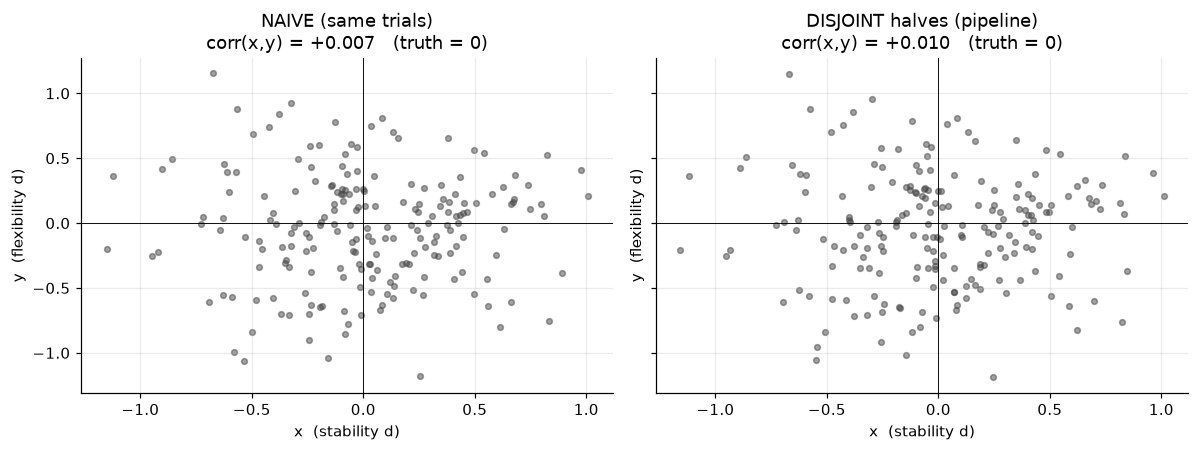

Naive shares trial noise -> inflated corr; disjoint estimator collapses it toward 0.


In [6]:
df0, _ = make_synthetic(rho_true=0.0, seed=7)   # ground truth: NO coupling

def naive_xy(frame):
    out = []
    for (s, e), g in frame.groupby(["subject", "electrode"]):
        x = sfs._cohens_d(g.loc[g.congruency == "i", "hg"], g.loc[g.congruency == "c", "hg"])
        y = sfs._cohens_d(g.loc[g.switchType == "s", "hg"], g.loc[g.switchType == "r", "hg"])
        out.append((x, y))
    return np.array(out)

naive = naive_xy(df0)
disj  = sfs.compute_sensitivities(df0, n_splits=40)[["x", "y"]].to_numpy()

from scipy.stats import pearsonr
def _r(a):
    m = np.isfinite(a).all(1); return pearsonr(a[m, 0], a[m, 1])[0]

fig, ax = plt.subplots(1, 2, figsize=(11, 4.2), sharex=True, sharey=True)
for a, dat, ttl in [(ax[0], naive, "NAIVE (same trials)"),
                    (ax[1], disj,  "DISJOINT halves (pipeline)")]:
    a.scatter(dat[:, 0], dat[:, 1], s=14, alpha=.5, color="#444")
    a.axhline(0, color="k", lw=.6); a.axvline(0, color="k", lw=.6)
    a.set(title=f"{ttl}\ncorr(x,y) = {_r(dat):+.3f}   (truth = 0)",
          xlabel="x  (stability d)", ylabel="y  (flexibility d)")
plt.tight_layout(); plt.show()
print("Naive shares trial noise -> inflated corr; disjoint estimator collapses it toward 0.")

Now compute the sensitivities on our **main** dataset (the one loaded in
§1), which we carry forward for the rest of the notebook.

(187, 4)


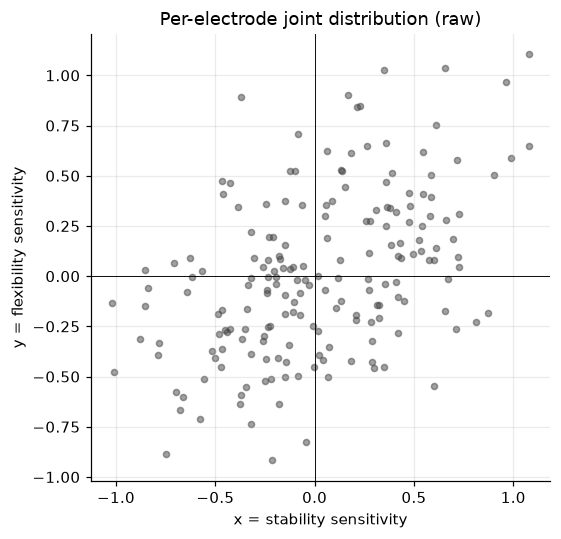

,subject,electrode,x,y
0,0,0_0,0.055747,0.355932
1,0,0_1,0.378011,0.341210
2,0,0_10,-0.577235,-0.710470
3,0,0_11,0.480073,0.348486
4,0,0_12,-0.352110,-0.262011


In [7]:
elec = sfs.compute_sensitivities(df, n_splits=60)
print(elec.shape)
fig, ax = plt.subplots(figsize=(5.2, 5))
ax.scatter(elec.x, elec.y, s=16, alpha=.5, color="#444")
ax.axhline(0, color="k", lw=.6); ax.axvline(0, color="k", lw=.6)
ax.set(title="Per-electrode joint distribution (raw)",
       xlabel="x = stability sensitivity", ylabel="y = flexibility sensitivity")
plt.tight_layout(); plt.show()
elec.head()

## 5 · `add_responsiveness` — measuring the gain confound

A high-SNR electrode has a larger effect for *everything*, so `|x|` and `|y|`
both scale with overall task drive — a **shared-gain** correlation that has
nothing to do with a shared *functional* core.

`add_responsiveness` attaches a per-electrode responsiveness score. In real
data you should pass your **baseline-vs-signal `time_perm_cluster` statistic**;
here we let it fall back to `mean|HG|`. The plot shows responsiveness driving
both `|x|` and `|y|` — exactly the nuisance we must regress out next.

In [ ]:
elec = sfs.add_responsiveness(elec, df, responsiveness=RESPONSIVENESS)  # None -> mean|HG| proxy
fig, ax = plt.subplots(1, 2, figsize=(10, 3.8))
for a, col, c, name in [(ax[0], "x", STAB, "|x| stability"),
                        (ax[1], "y", FLEX, "|y| flexibility")]:
    a.scatter(elec.resp, elec[col].abs(), s=15, alpha=.5, color=c)
    b1, b0 = np.polyfit(elec.resp, elec[col].abs(), 1)
    xs = np.linspace(elec.resp.min(), elec.resp.max(), 50)
    a.plot(xs, b0 + b1*xs, color="k", lw=1.2)
    a.set(title=f"responsiveness -> {name}", xlabel="responsiveness (resp)",
          ylabel=name)
plt.tight_layout(); plt.show()

## 6 · `_ols_resid` + `prepare_continuous` — two corrections stacked

`prepare_continuous` does two things, in order:

1. **Residualize on responsiveness** (`_ols_resid`): fit `x ~ resp` and
   `y ~ resp`, keep the residuals `x1, y1`. This strips the gain-driven
   co-inflation, so any leftover `x1`↔`y1` relationship is *functional*, not SNR.
2. **Within-subject center**: subtract each subject's mean of `x1` (and `y1`).
   This removes between-subject differences, leaving only **within-subject**
   co-selectivity — which is exactly what the within-subject permutation null
   (next section) tests. Subjects with `< min_elec` electrodes are dropped.

The panels below show the same electrodes at each stage.

electrodes kept: 187 | subjects: 10


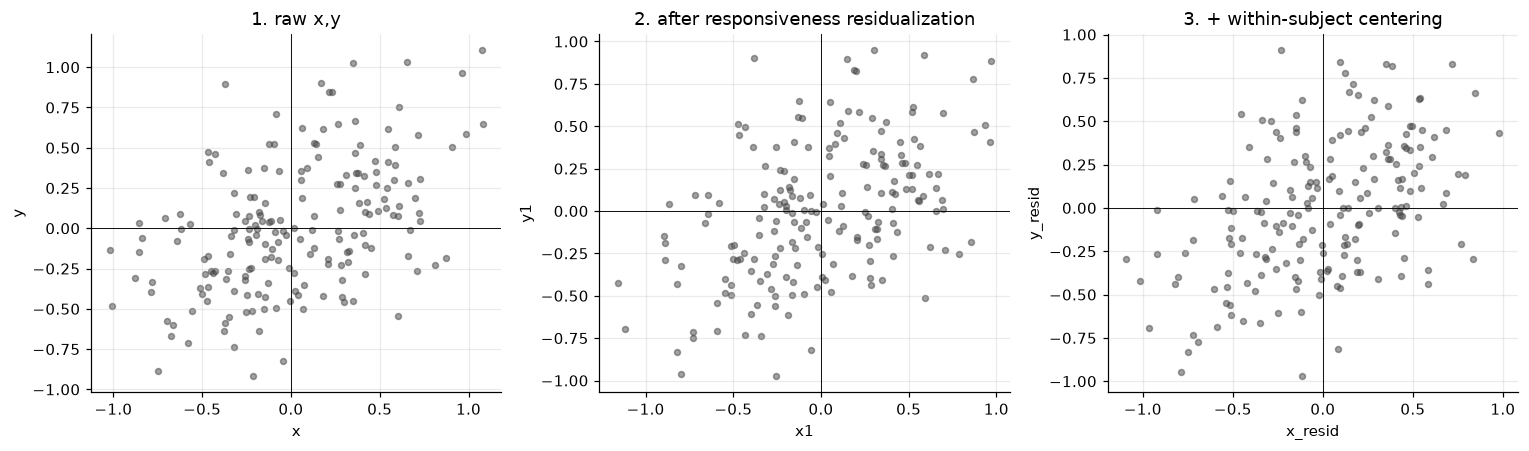

In [9]:
cont = sfs.prepare_continuous(elec, min_elec=3)
print("electrodes kept:", len(cont), "| subjects:", cont.subject.nunique())

fig, ax = plt.subplots(1, 3, figsize=(14, 4.2))
stages = [("x", "y", "1. raw x,y"),
          ("x1", "y1", "2. after responsiveness residualization"),
          ("x_resid", "y_resid", "3. + within-subject centering")]
for a, (cx, cy, ttl) in zip(ax, stages):
    src = elec if cx == "x" else cont
    a.scatter(src[cx], src[cy], s=15, alpha=.5, color="#444")
    a.axhline(0, color="k", lw=.6); a.axvline(0, color="k", lw=.6)
    a.set(title=ttl, xlabel=cx, ylabel=cy)
plt.tight_layout(); plt.show()

## 7 · `subject_clustered_corr` — the continuous test

Now the actual test. We take `corr(x_resid, y_resid)` (Spearman by default) as
the observed statistic, then build a **null by permuting `y` within each
subject**. Shuffling only inside subjects preserves the between-subject
structure, so the test isolates the **within-subject** association — matching
what the centering set up.

`p = (#{|null| ≥ |obs|} + 1) / (n_perm + 1)`.

In [ ]:
res = sfs.subject_clustered_corr(cont, method="spearman", n_perm=2000)
print(res)

# rebuild the null explicitly so we can plot it (mirrors the function internals)
from scipy.stats import spearmanr
xr, yr = cont.x_resid.to_numpy(), cont.y_resid.to_numpy()
subj = cont.subject.to_numpy()
groups = [np.where(subj == s)[0] for s in np.unique(subj)]
rng = np.random.default_rng(1)
null = np.empty(2000)
for i in range(2000):
    yp = yr.copy()
    for idx in groups:
        yp[idx] = yr[rng.permutation(idx)]
    null[i] = spearmanr(xr, yp)[0]

fig, ax = plt.subplots(figsize=(7.5, 4))
ax.hist(null, bins=40, color="#bbb", label="within-subject permutation null")
ax.axvline(res["corr"], color="#d7191c", lw=2,
           label=f"observed = {res['corr']:+.3f}")
ax.set(title=f"Continuous test: Spearman corr(x,y)   p = {res['p']:.4f}"
             f"{TRUTH_LABEL}",
       xlabel="Spearman correlation", ylabel="# permutations")
ax.legend(); plt.tight_layout(); plt.show()
print("corr > 0 & significant -> shared core;  corr <= 0 -> segregation")

### Optional cross-check: `mixedlm_check`

A linear mixed model `y1 ~ x1` with a subject random intercept gives the same
within-subject slope from a parametric angle. Agreement with the permutation
result is reassuring.

In [11]:
try:
    print(sfs.mixedlm_check(cont))
except Exception as e:
    print("mixedlm skipped:", e)

{'slope': np.float64(0.41234430659616583), 'p': np.float64(1.1157742137511162e-05)}


/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.11/dist-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.11/dist-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with cg
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "

## 8 · `per_electrode_labels` — binarize into S and F

The categorical test needs each electrode tagged **S** (stability-selective)
and/or **F** (flexibility-selective). For each electrode we get a
within-electrode permutation p-value for the congruency and switch contrasts
(shuffling the condition labels), then **FDR-correct across electrodes** and
threshold at `alpha`. `S`/`F` are 0/1 flags.

We plot the p-value distributions and how many electrodes land in each
selectivity class.

{'S': 120, 'F': 105} of 187 electrodes


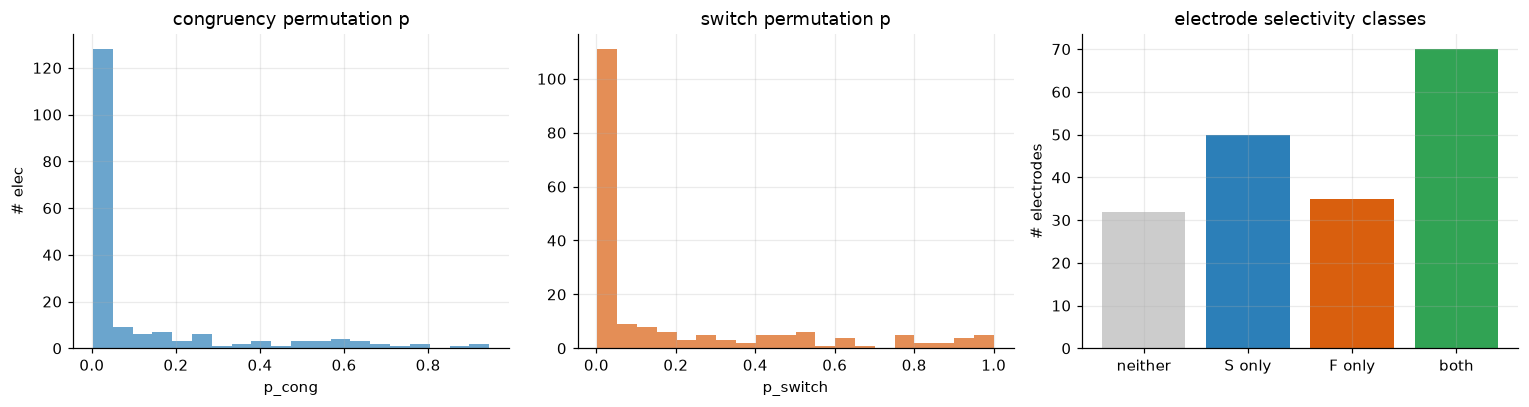

In [12]:
labels = sfs.per_electrode_labels(df, n_perm=400, alpha=0.05)
print(labels[["S", "F"]].sum().to_dict(), "of", len(labels), "electrodes")

fig, ax = plt.subplots(1, 3, figsize=(14, 3.8))
ax[0].hist(labels.p_cong.dropna(), bins=20, color=STAB, alpha=.7)
ax[0].set(title="congruency permutation p", xlabel="p_cong", ylabel="# elec")
ax[1].hist(labels.p_switch.dropna(), bins=20, color=FLEX, alpha=.7)
ax[1].set(title="switch permutation p", xlabel="p_switch")

# selectivity classes
both = ((labels.S == 1) & (labels.F == 1)).sum()
so   = ((labels.S == 1) & (labels.F == 0)).sum()
fo   = ((labels.S == 0) & (labels.F == 1)).sum()
neither = ((labels.S == 0) & (labels.F == 0)).sum()
ax[2].bar(["neither", "S only", "F only", "both"], [neither, so, fo, both],
          color=["#ccc", STAB, FLEX, "#31a354"])
ax[2].set(title="electrode selectivity classes", ylabel="# electrodes")
plt.tight_layout(); plt.show()

The `q_cong` vs `q_switch` scatter makes the 2×2 conjunction visible:
the dashed lines are the `alpha` thresholds, and the four quadrants are exactly
the *neither / S-only / F-only / both* cells the CMH test will count.

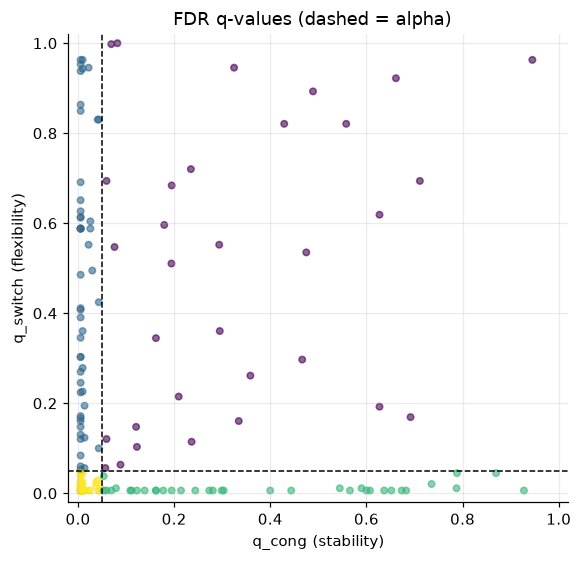

In [13]:
fig, ax = plt.subplots(figsize=(5.4, 5.2))
sc = ax.scatter(labels.q_cong, labels.q_switch, s=18, alpha=.6,
                c=(labels.S + 2*labels.F), cmap="viridis")
ax.axvline(0.05, color="k", ls="--", lw=1); ax.axhline(0.05, color="k", ls="--", lw=1)
ax.set(title="FDR q-values (dashed = alpha)  ", xlabel="q_cong (stability)",
       ylabel="q_switch (flexibility)", xlim=(-.02, 1.02), ylim=(-.02, 1.02))
plt.tight_layout(); plt.show()

## 9 · `cmh_conjunction` — subject-stratified 2×2 (CMH)

Finally the categorical test. Each **subject** contributes its own 2×2 table of
electrode counts:

|        | F = 1 | F = 0 |
|--------|-------|-------|
| **S=1**| both  | stability-only |
| **S=0**| flex-only | neither |

The **Cochran–Mantel–Haenszel** procedure pools these tables *while respecting
subject strata* (the categorical analogue of the within-subject permutation),
and returns a **common odds ratio**:

- **MH OR < 1** → S and F tend to occur in *different* electrodes → **segregation**
- **MH OR > 1** → S and F co-occur → **shared core**

It also gives the CMH test (H₀: OR = 1) and a homogeneity test (are the strata
consistent?). The pooled Fisher table at the bottom is descriptive only (it
ignores subject nesting).

In [14]:
conj = sfs.cmh_conjunction(labels)
print(f"MH odds ratio = {conj['mh_odds_ratio']:.3f}")
print(f"CMH test p    = {conj['cmh'].pvalue:.4f}   (H0: OR=1)")
print(f"homogeneity p = {conj['homogeneity'].pvalue:.4f}   (H0: OR equal across subjects)")
if "or_95ci" in conj:
    print("MH OR 95% CI  =", tuple(round(v, 3) for v in conj["or_95ci"]))
print("pooled Fisher OR =", round(conj["pooled_fisher_or"], 3),
      "p =", round(conj["pooled_fisher_p"], 4))
conj["per_subject"].head()

MH odds ratio = 1.273
CMH test p    = 0.4509   (H0: OR=1)
homogeneity p = 0.5864   (H0: OR equal across subjects)
MH OR 95% CI  = (np.float64(0.683), np.float64(2.373))
pooled Fisher OR = 1.28 p = 0.4453


,subject,both,stab_only,flex_only,neither
0,0,10,4,4,1
1,1,5,5,4,4
2,2,6,5,2,2
3,3,4,3,3,5
4,4,11,5,3,2


/tmp/ipykernel_8517/842543977.py:15: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  ps["p_F_overall"]   = (ps.both + ps.flex_only) / ps[["both","stab_only","flex_only","neither"]].sum(1)


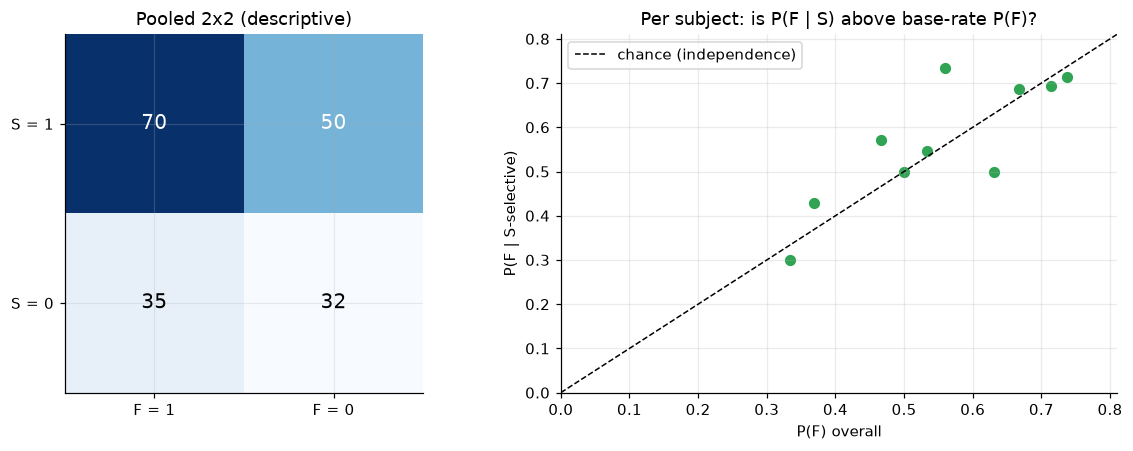

Points above the diagonal -> overlap; on/below -> segregation.


In [15]:
pooled = conj["pooled_table"]         # [[both, S-only],[F-only, neither]]
fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))

im = ax[0].imshow(pooled, cmap="Blues")
ax[0].set_xticks([0, 1]); ax[0].set_xticklabels(["F = 1", "F = 0"])
ax[0].set_yticks([0, 1]); ax[0].set_yticklabels(["S = 1", "S = 0"])
for (i, j), v in np.ndenumerate(pooled):
    ax[0].text(j, i, int(v), ha="center", va="center",
               color="white" if v > pooled.max()/2 else "black", fontsize=13)
ax[0].set(title="Pooled 2x2 (descriptive)")

# per-subject odds-ratio-ish view: fraction of S-electrodes that are also F
ps = conj["per_subject"].copy()
ps["p_both_given_S"] = ps.both / (ps.both + ps.stab_only).replace(0, np.nan)
ps["p_F_overall"]   = (ps.both + ps.flex_only) / ps[["both","stab_only","flex_only","neither"]].sum(1)
ax[1].scatter(ps.p_F_overall, ps.p_both_given_S, s=40, color="#31a354")
lim = [0, max(0.05, np.nanmax([ps.p_F_overall.max(), ps.p_both_given_S.max()])*1.1)]
ax[1].plot(lim, lim, "k--", lw=1, label="chance (independence)")
ax[1].set(title="Per subject: is P(F | S) above base-rate P(F)?",
          xlabel="P(F) overall", ylabel="P(F | S-selective)", xlim=lim, ylim=lim)
ax[1].legend(); plt.tight_layout(); plt.show()
print("Points above the diagonal -> overlap; on/below -> segregation.")

## 10 · Putting it together — `run_joint_distribution_analysis`

The orchestrator chains everything: sensitivities → responsiveness →
continuous test, and labels → CMH. Here it is end-to-end with the same data,
plus an interpretation summary.

In [ ]:
out = sfs.run_joint_distribution_analysis(
    df, responsiveness=RESPONSIVENESS,
    n_splits=60, n_perm_corr=2000, n_perm_label=400)

c = out["correlation"]; k = out["conjunction"]
print("CONTINUOUS  corr = {:+.3f}  p = {:.4f}  (n_elec={}, n_subj={})".format(
      c["corr"], c["p"], c["n_electrodes"], c["n_subjects"]))
print("CATEGORICAL MH OR = {:.3f}  CMH p = {:.4f}".format(
      k["mh_odds_ratio"], k["cmh"].pvalue))

def verdict(corr, p_c, orr, p_k, a=0.05):
    cont_v = ("shared core" if corr > 0 else "segregated") + \
             (" (sig.)" if p_c < a else " (n.s.)")
    cat_v  = ("shared core" if orr > 1 else "segregated") + \
             (" (sig.)" if p_k < a else " (n.s.)")
    return cont_v, cat_v
cv, kv = verdict(c["corr"], c["p"], k["mh_odds_ratio"], k["cmh"].pvalue)
print("\ncontinuous verdict :", cv)
print("categorical verdict:", kv)

## 11 · Interpretation cheat-sheet

| Continuous `corr(x,y)` | Categorical MH OR | Reading |
|---|---|---|
| ≤ 0 (sig.) | < 1 (sig.) | **Segregation** — distinct subpopulations for stability vs. flexibility |
| > 0 (sig.) | > 1 (sig.) | **Shared / domain-general core** — same electrodes do both |
| ≈ 0 (n.s.) | ≈ 1 (n.s.) | Underpowered or genuinely independent — report as no evidence either way |
| disagree | disagree | Continuous is graded & powered; categorical is robust to outliers. Reconcile via the plots above |

**Before trusting the numbers, confirm the corrections did their job:**
- §4 disjoint-vs-naive scatter — the split estimator removed the shared-noise tilt.
- §5–§6 residualization panels — responsiveness no longer drives `x_resid`, `y_resid`.
- §7 null histogram — the observed value is read against a *within-subject* null.
- §9 homogeneity p — if small, subjects disagree and the pooled OR hides heterogeneity.

**On real data:** set `DATA_SOURCE="real"` in §1 (via `LONG_DF_CSV` or
`SUBJECTS`+`EPOCHS_ROOT_FILE`), set `RESPONSIVENESS` to your baseline-vs-signal
`time_perm_cluster` statistic as `{electrode: value}` (better gain control than
`mean|HG|`), and raise `n_splits`, `n_perm_corr`, and `n_perm_label` for
publication-grade estimates. The production entrypoint
`dcc_scripts/stats/run_stability_flexibility_segregation_dcc.py` runs this same
analysis at scale and now also writes a `segregation_diagnostics.png` with the
QC panels from this notebook.

## 12 · Optional variants — proportion contrasts & cluster-mass effects

Everything above used the two defaults: contrasts defined by the **trial**
condition (`congruency` i-vs-c, `switchType` s-vs-r) and each effect measured as
**Cohen's _d_** on the window-mean HG. The pipeline exposes two independent,
combinable knobs on `compute_sensitivities`, `per_electrode_labels`, and
`run_joint_distribution_analysis` (both default to the originals, so nothing
above changes):

- **`contrast_mode`** — `'condition'` (default) or **`'proportion'`**, which
  defines stability from the block **`incongruent_proportion`** (high vs low,
  the LWPC manipulation) and flexibility from **`switch_proportion`** (LWPS).
  Needs those columns in `df`; the DCC assembly adds them automatically.
- **`effect_measure`** — `'cohens_d'` (default) or **`'cluster'`**, which scores
  each contrast by its **aggregate cluster-mass statistic** (signed summed
  statistic over the significant time bins — the same quantity
  `ieeg.calc.stats.time_perm_cluster` reports) instead of a difference of window
  means. This needs the per-trial HG **time course** rather than a scalar, so
  `df.hg` holds a 1-D array per trial. By default the mass uses a fast
  deterministic parametric threshold; set `sfs.USE_TIME_PERM_CLUSTER = True` to
  use the real `time_perm_cluster` mask (slower — it permutes on every call).

Below we exercise both, using `sfs._synthetic_df`, which carries the proportion
columns and can emit time-resolved HG.

In [ ]:
# --- proportion contrasts (still Cohen's d on window-mean HG) ----------------
df_prop = sfs._synthetic_df(effect_measure="cohens_d", seed=3)
out_prop = sfs.run_joint_distribution_analysis(
    df_prop, n_splits=40, n_perm_corr=1500, n_perm_label=300,
    contrast_mode="proportion")
cp, kp = out_prop["correlation"], out_prop["conjunction"]
print("PROPORTION  corr = {:+.3f}  p = {:.4f}   MH OR = {:.3f}  CMH p = {:.4f}".format(
      cp["corr"], cp["p"], kp["mh_odds_ratio"], kp["cmh"].pvalue))

# --- cluster-mass effect on time-resolved HG (condition contrasts) ----------
df_clu = sfs._synthetic_df(effect_measure="cluster", n_time=20, seed=3)
print("df_clu.hg[0] is a time course of shape:", df_clu.hg.iloc[0].shape)
out_clu = sfs.run_joint_distribution_analysis(
    df_clu, n_splits=15, n_perm_corr=1000, n_perm_label=150,
    effect_measure="cluster")
cc, kc = out_clu["correlation"], out_clu["conjunction"]
print("CLUSTER     corr = {:+.3f}  p = {:.4f}   MH OR = {:.3f}  CMH p = {:.4f}".format(
      cc["corr"], cc["p"], kc["mh_odds_ratio"], kc["cmh"].pvalue))